<a href="https://colab.research.google.com/github/PedroNishimura/feedback_model/blob/main/feedbackModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [ ]:
csv_path = "/content/dataset.csv"

In [ ]:
df_feedbacks = pd.read_csv(csv_path)

In [ ]:
df_feedbacks.shape

(500, 3)

In [ ]:
df_feedbacks.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [ ]:
df_feedbacks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


In [ ]:
df_feedbacks.isnull().sum()

,0
review_id,0
texto_review,12
sentimento,0


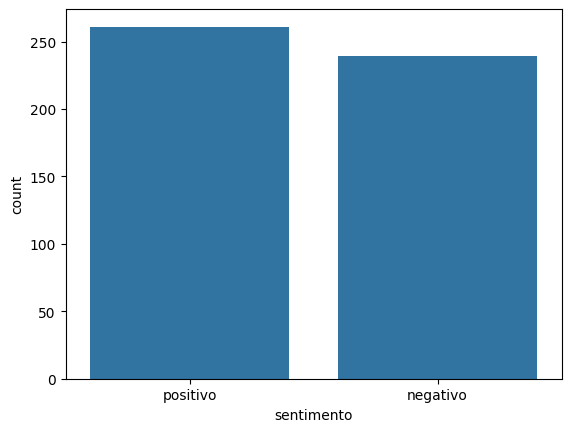

In [ ]:
sns.countplot(x="sentimento", data=df_feedbacks)
plt.show()
#

In [ ]:
df_feedbacks.dropna(subset = ['texto_review'], inplace = True)
print(len(df_feedbacks))

488


In [ ]:
# Função de limpeza de texto
def clear_text(text):
    """
    Complete function to clean a text:
    1. Converge to lowercase.
    2. Remove accents.
    3. Remove points, numbers and specials caracters.
    4. Remove extra space.
    """

    if not isinstance(text, str):
        return ""

    text_without_accents = ''.join(c for c in unicodedata.normalize('NFKD', text) if unicodedata.category(c) != 'Mn')

    clear_text = text_without_accents.lower()

    clear_text = re.sub(r'[^a-z\s]', '', clear_text)

    clear_text = re.sub(r'\s+', ' ', clear_text).strip()

    return clear_text

In [ ]:
df_feedbacks['clear_text'] = df_feedbacks['texto_review'].apply(clear_text)

In [ ]:
df_feedbacks.head()

,review_id,texto_review,sentimento,clear_text
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


In [ ]:
df_feedbacks['sentiment_label'] = df_feedbacks['sentimento'].map({'negativo': 0, 'positivo': 1})

In [ ]:
X = df_feedbacks['clear_text']
y = df_feedbacks['sentiment_label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
pipeline = Pipeline([

    ('tfidf', TfidfVectorizer(stop_words = ['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um'])),

    ('scaler', StandardScaler(with_mean = False)),

    ('logreg', LogisticRegression(solver = 'liblinear', random_state = 42, max_iter = 1000))
])

In [ ]:
parameters_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [5000, 6000]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,              # Pipeline com as etapas de pré-processamento e modelo
    parameters_grid,       # Dicionário com as combinações de hiperparâmetros a serem testadas
    cv = 5,                # Número de divisões para validação cruzada (5-fold cross-validation)
    n_jobs = -1,           # Usa todos os núcleos disponíveis do processador para acelerar o processo
    scoring = 'accuracy',  # Métrica usada para avaliar o desempenho de cada combinação (aqui, acurácia)
    verbose = 1            # Nível de detalhamento do output durante a execução (1 exibe progresso básico)
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words=['de', 'a',
                                                                    'o', 'que',
                                                                    'e', 'do',
                                                                    'da', 'em',
                                                                    'um'])),
                                       ('scaler',
                                        StandardScaler(with_mean=False)),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'logreg__C': [0.1, 1, 10],
                         'logreg__max_iter': [5000, 6000],
                         'logreg__penalty': ['l1', 'l2'],
                         'tfidf__max_features': [500, 1000, 2000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search.best_params_)

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = ['Negative', 'Positive'])

In [ ]:
print(accuracy)
print('\n##############################################################\n')
print(report)

0.8114754098360656

##############################################################

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.80        58
    Positive       0.83      0.81      0.82        64

    accuracy                           0.81       122
   macro avg       0.81      0.81      0.81       122
weighted avg       0.81      0.81      0.81       122



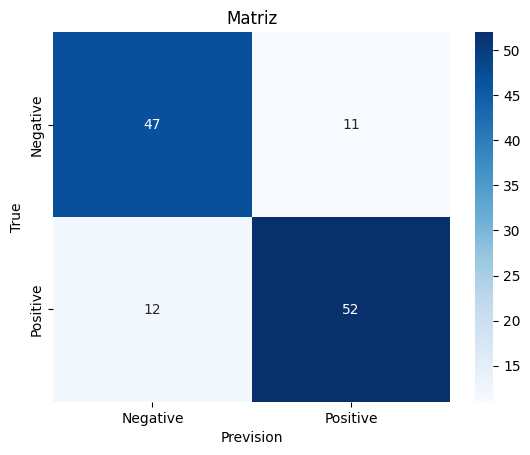

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Negative', 'Positive'],
            yticklabels = ['Negative', 'Positive'])
plt.xlabel('Prevision')
plt.ylabel('True')
plt.title('Matriz')
plt.show()

In [ ]:
joblib.dump(best_model, 'feedbackModelV1.joblib')

del best_model

In [ ]:
model_deploy = joblib.load('feedbackModelV1.joblib')

In [ ]:
new_reviews = [
    "A bateria do celular não dura nada, péssima compra.",
    "Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.",
    "O serviço de atendimento foi rápido e eficiente.",
    "Não recomendo, veio faltando peças e a cor estava errada."
]

In [ ]:
def prev_sentiment(reviews):
    """
    Receive a list of texts reviews and returns prev of sentiment.
    """

    # 1. 'reviews' entra no pipeline
    # 2. TF-IDF é aplicado internamente
    # 3. StandardScaler é aplicado internamente
    # 4. LogisticRegression faz a previsão
    prev = model_deploy.predict(reviews)

    # Mapeia o resultado numérico de volta para texto
    sentiments = ['Negative' if p == 0 else 'Positive' for p in prev]

    # Exibe os resultados
    for review, sentiment in zip(reviews, sentiments):
        print(f"\nReview: '{review}'\nPrev Sentiment: {sentiment}\n---")

In [ ]:
prev_sentiment(new_reviews)


Review: 'A bateria do celular não dura nada, péssima compra.'
Prev Sentiment: Negative
---

Review: 'Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.'
Prev Sentiment: Positive
---

Review: 'O serviço de atendimento foi rápido e eficiente.'
Prev Sentiment: Negative
---

Review: 'Não recomendo, veio faltando peças e a cor estava errada.'
Prev Sentiment: Negative
---
